In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import adjusted_rand_score, homogeneity_score, completeness_score
from sklearn.decomposition import PCA

# AuSiO2

## LD=2

Loading data.

In [2]:
ld2_ausio2 = np.load('../../best_models/ld2_ausio2_ausio2.npy')
labels = np.load('../../dataset_TipAu_SiO2_annotated.npz')['labels']

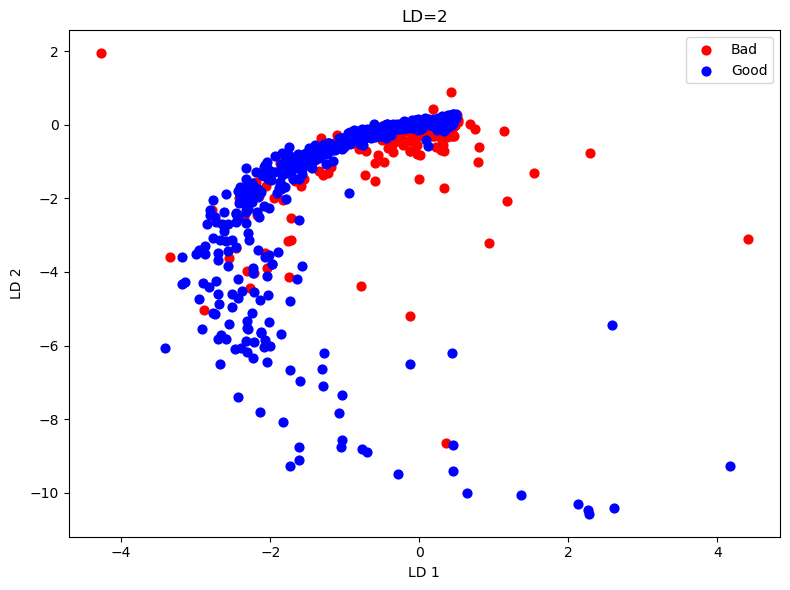

In [3]:
colors = ['red', 'blue']

plt.figure(figsize=(8, 6))
plt.scatter(ld2_ausio2[labels == 0][:, 0], ld2_ausio2[labels == 0][:, 1], label='Bad', s=40, color=colors[0])
plt.scatter(ld2_ausio2[labels == 1][:, 0], ld2_ausio2[labels == 1][:, 1], label='Good', s=40, color=colors[1])
plt.legend()
plt.title("LD=2")
plt.xlabel("LD 1")
plt.ylabel("LD 2")
plt.tight_layout()
plt.show()

Clustering LD=2 with Ward hierarchical clustering.

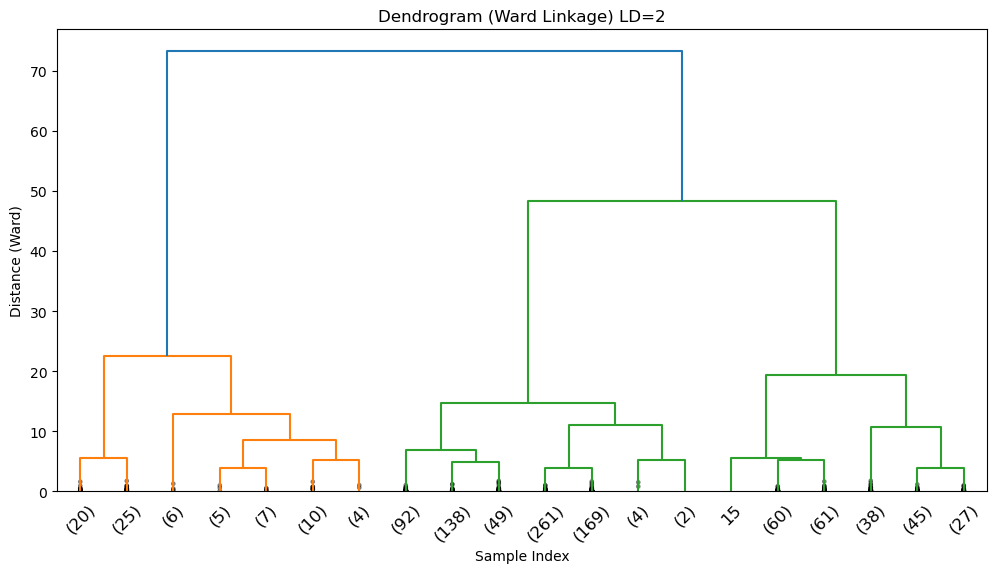

In [4]:
linked_ld2 = linkage(ld2_ausio2, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(
    linked_ld2, 
    truncate_mode='lastp',  
    p=20,                  
    leaf_rotation=45.,
    leaf_font_size=12.,
    show_contracted=True
)
plt.title('Dendrogram (Ward Linkage) LD=2')
plt.xlabel('Sample Index')
plt.ylabel('Distance (Ward)')
plt.show()

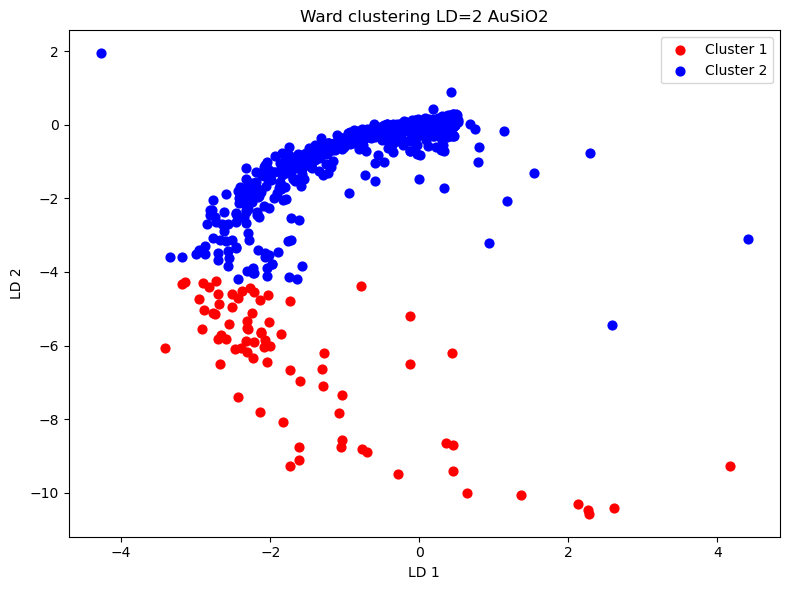

In [5]:
cluster_labels_ld2 = fcluster(linked_ld2, t=2, criterion='maxclust')

plt.figure(figsize=(8, 6))
for cluster_id in np.unique(cluster_labels_ld2):
    mask = (cluster_labels_ld2 == cluster_id)
    plt.scatter(ld2_ausio2[mask, 0], ld2_ausio2[mask, 1], label=f"Cluster {cluster_id}", s=40, c=colors[cluster_id - 1])
plt.legend()
plt.title("Ward clustering LD=2 AuSiO2")
plt.xlabel("LD 1")
plt.ylabel("LD 2")
plt.tight_layout()
plt.show()

In [6]:
cluster_encoder = LabelEncoder()
cluster_labels_num = cluster_encoder.fit_transform(cluster_labels_ld2)

ari = adjusted_rand_score(labels, cluster_labels_ld2)
hom = homogeneity_score(labels, cluster_labels_ld2)
comp = completeness_score(labels, cluster_labels_ld2)

print(f"Ajusted Rand Index (ARI): {ari:.3f}")
print(f"Homogeneinity: {hom:.3f}")
print(f"Completeness: {comp:.3f}")

Ajusted Rand Index (ARI): -0.012
Homogeneinity: 0.041
Completeness: 0.105


## LD=3

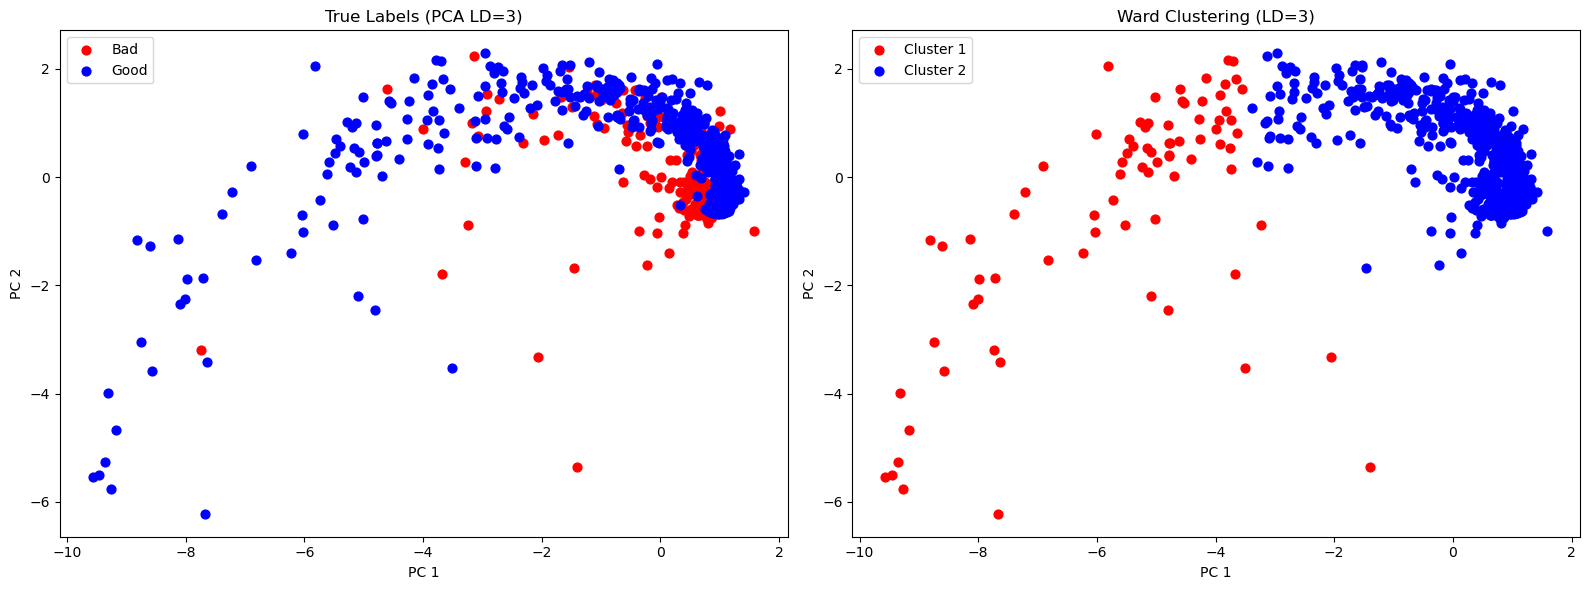

In [7]:
ld3_ausio2 = np.load('../../best_models/ld3_ausio2_ausio2.npy')
labels = np.load('../../dataset_TipAu_SiO2_annotated.npz')['labels']

linked_ld3 = linkage(ld3_ausio2, method='ward')
cluster_labels_3 = fcluster(linked_ld3, t=2, criterion='maxclust')

pca = PCA(n_components=2)
ld3_pca = pca.fit_transform(ld3_ausio2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6)) 

ax1.scatter(ld3_pca[labels == 0][:, 0], ld3_pca[labels == 0][:, 1], label='Bad', s=40, color=colors[0])
ax1.scatter(ld3_pca[labels == 1][:, 0], ld3_pca[labels == 1][:, 1], label='Good', s=40, color=colors[1])
ax1.set_title("True Labels (PCA LD=3)")
ax1.set_xlabel("PC 1")
ax1.set_ylabel("PC 2")
ax1.legend()

for cluster_id in np.unique(cluster_labels_3):
    mask = (cluster_labels_3 == cluster_id)
    ax2.scatter(ld3_pca[mask, 0], ld3_pca[mask, 1], 
                label=f"Cluster {cluster_id}", s=40, c=colors[cluster_id - 1])
ax2.set_title("Ward Clustering (LD=3)")
ax2.set_xlabel("PC 1")
ax2.set_ylabel("PC 2")
ax2.legend()

plt.tight_layout()
plt.show()

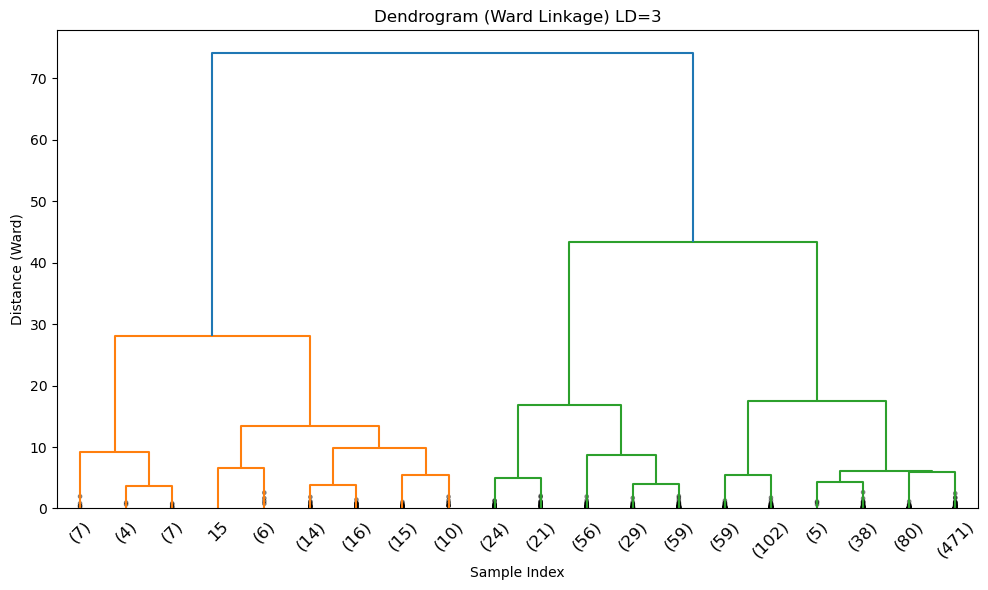

In [8]:
plt.figure(figsize=(10, 6))
dendrogram(
    linked_ld3, 
    truncate_mode='lastp',  
    p=20,                  
    leaf_rotation=45.,
    leaf_font_size=12.,
    show_contracted=True
)
plt.title('Dendrogram (Ward Linkage) LD=3')
plt.xlabel('Sample Index')
plt.ylabel('Distance (Ward)')
plt.tight_layout()
plt.show()

In [9]:
cluster_encoder = LabelEncoder()
cluster_labels_num = cluster_encoder.fit_transform(cluster_labels_3)

ari_3 = adjusted_rand_score(labels, cluster_labels_3)
homogeneity_3 = homogeneity_score(labels, cluster_labels_3)
completeness_3 = completeness_score(labels, cluster_labels_3)

print(f"Adjusted Rand Index (ARI):, {ari_3:.3f}")
print(f"Homogeneity: {homogeneity_3:.3f}")
print(f"Completeness: {completeness_3:.3f}")

Adjusted Rand Index (ARI):, -0.012
Homogeneity: 0.037
Completeness: 0.091


## LD=5

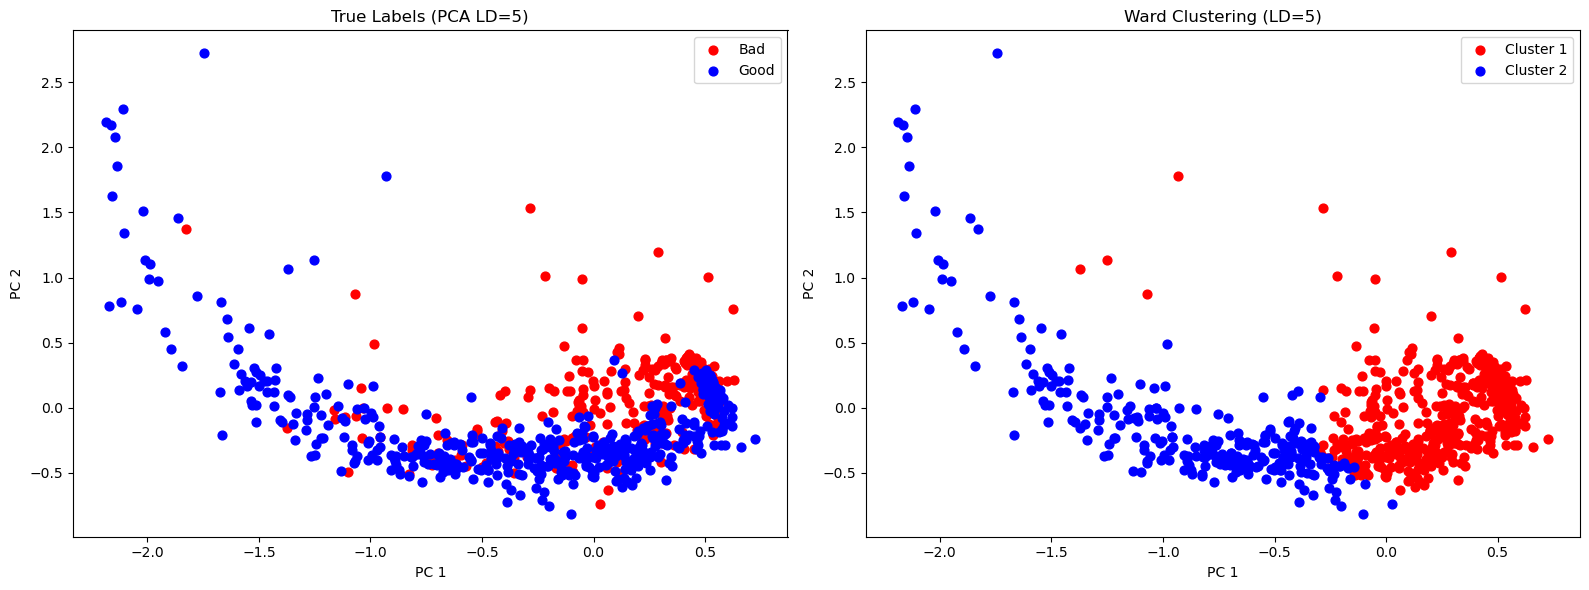

In [10]:
ld5_ausio2 = np.load('../../best_models/ld5_ausio2_ausio2.npy')
labels = np.load('../../dataset_TipAu_SiO2_annotated.npz')['labels']

linked_ld5 = linkage(ld5_ausio2, method='ward')
cluster_labels_5 = fcluster(linked_ld5, t=2, criterion='maxclust')

pca = PCA(n_components=2)
ld5_pca = pca.fit_transform(ld5_ausio2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6)) 

ax1.scatter(ld5_pca[labels == 0][:, 0], ld5_pca[labels == 0][:, 1], label='Bad', s=40, color=colors[0])
ax1.scatter(ld5_pca[labels == 1][:, 0], ld5_pca[labels == 1][:, 1], label='Good', s=40, color=colors[1])
ax1.set_title("True Labels (PCA LD=5)")
ax1.set_xlabel("PC 1")
ax1.set_ylabel("PC 2")
ax1.legend()

for cluster_id in np.unique(cluster_labels_5):
    mask = (cluster_labels_5 == cluster_id)
    ax2.scatter(ld5_pca[mask, 0], ld5_pca[mask, 1], 
                label=f"Cluster {cluster_id}", s=40, c=colors[cluster_id - 1])
ax2.set_title("Ward Clustering (LD=5)")
ax2.set_xlabel("PC 1")
ax2.set_ylabel("PC 2")
ax2.legend()

plt.tight_layout()
plt.show()

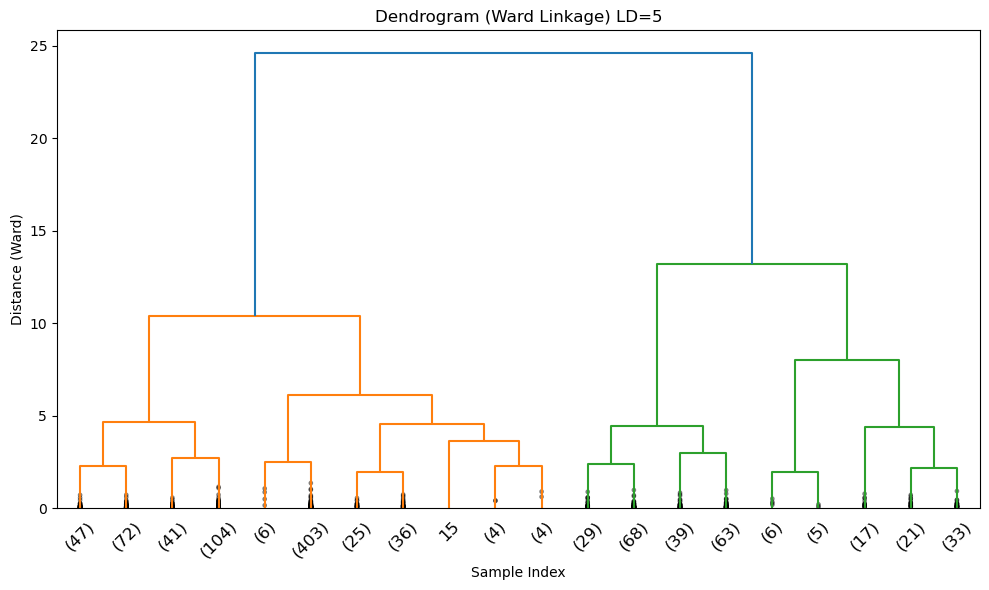

In [11]:
plt.figure(figsize=(10, 6))
dendrogram(
    linked_ld5, 
    truncate_mode='lastp',  
    p=20,                  
    leaf_rotation=45.,
    leaf_font_size=12.,
    show_contracted=True
)
plt.title('Dendrogram (Ward Linkage) LD=5')
plt.xlabel('Sample Index')
plt.ylabel('Distance (Ward)')
plt.tight_layout()
plt.show()

In [12]:
cluster_encoder = LabelEncoder()
cluster_labels_num = cluster_encoder.fit_transform(cluster_labels_5)

ari_5 = adjusted_rand_score(labels, cluster_labels_5)
homogeneity_5 = homogeneity_score(labels, cluster_labels_5)
completeness_5 = completeness_score(labels, cluster_labels_5)

print(f"Adjusted Rand Index (ARI):, {ari_5:.3f}")
print(f"Homogeneity: {homogeneity_5:.3f}")
print(f"Completeness: {completeness_5:.3f}")

Adjusted Rand Index (ARI):, 0.046
Homogeneity: 0.078
Completeness: 0.091


## LD=10

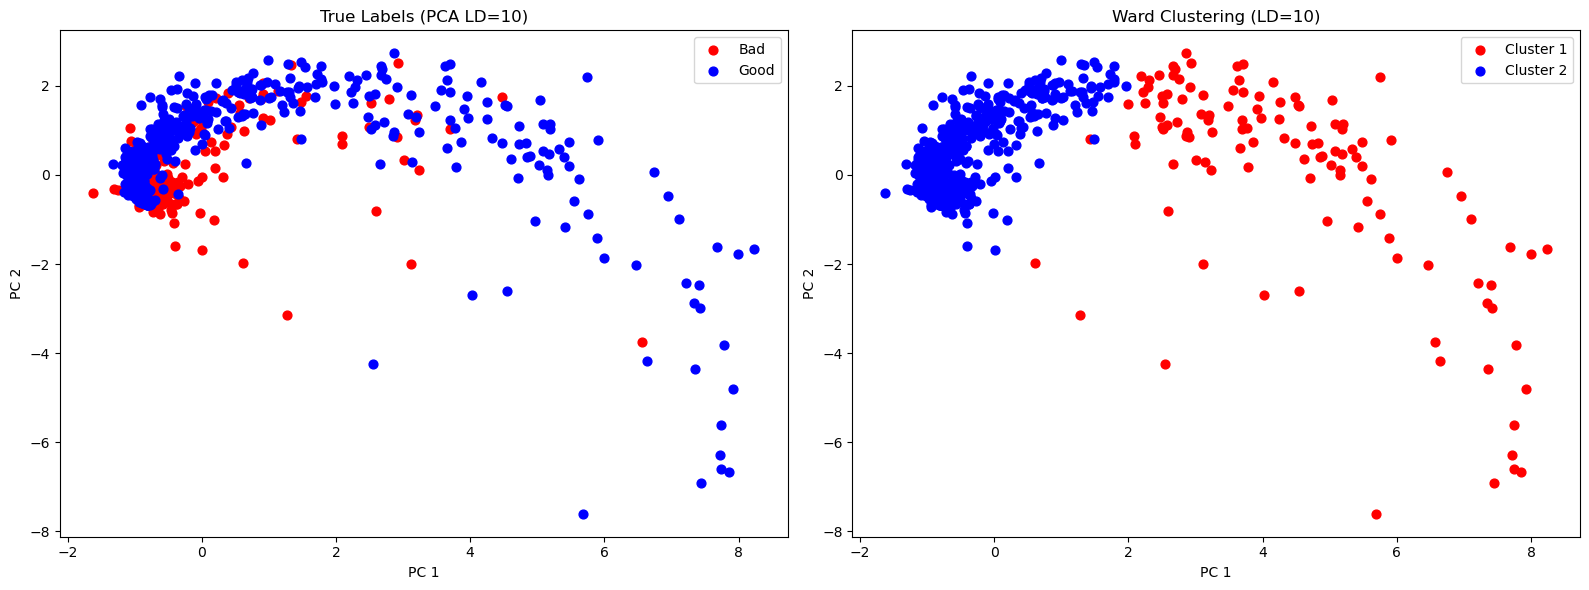

In [13]:
ld10_ausio2 = np.load('../../best_models/ld10_ausio2_ausio2.npy')
labels = np.load('../../dataset_TipAu_SiO2_annotated.npz')['labels']

linked_ld10 = linkage(ld10_ausio2, method='ward')
cluster_labels_10 = fcluster(linked_ld10, t=2, criterion='maxclust')

pca = PCA(n_components=2)
ld10_pca = pca.fit_transform(ld10_ausio2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6)) 

ax1.scatter(ld10_pca[labels == 0][:, 0], ld10_pca[labels == 0][:, 1], label='Bad', s=40, color=colors[0])
ax1.scatter(ld10_pca[labels == 1][:, 0], ld10_pca[labels == 1][:, 1], label='Good', s=40, color=colors[1])
ax1.set_title("True Labels (PCA LD=10)")
ax1.set_xlabel("PC 1")
ax1.set_ylabel("PC 2")
ax1.legend()

for cluster_id in np.unique(cluster_labels_10):
    mask = (cluster_labels_10 == cluster_id)
    ax2.scatter(ld10_pca[mask, 0], ld10_pca[mask, 1], 
                label=f"Cluster {cluster_id}", s=40, c=colors[cluster_id - 1])
ax2.set_title("Ward Clustering (LD=10)")
ax2.set_xlabel("PC 1")
ax2.set_ylabel("PC 2")
ax2.legend()

plt.tight_layout()
plt.show()

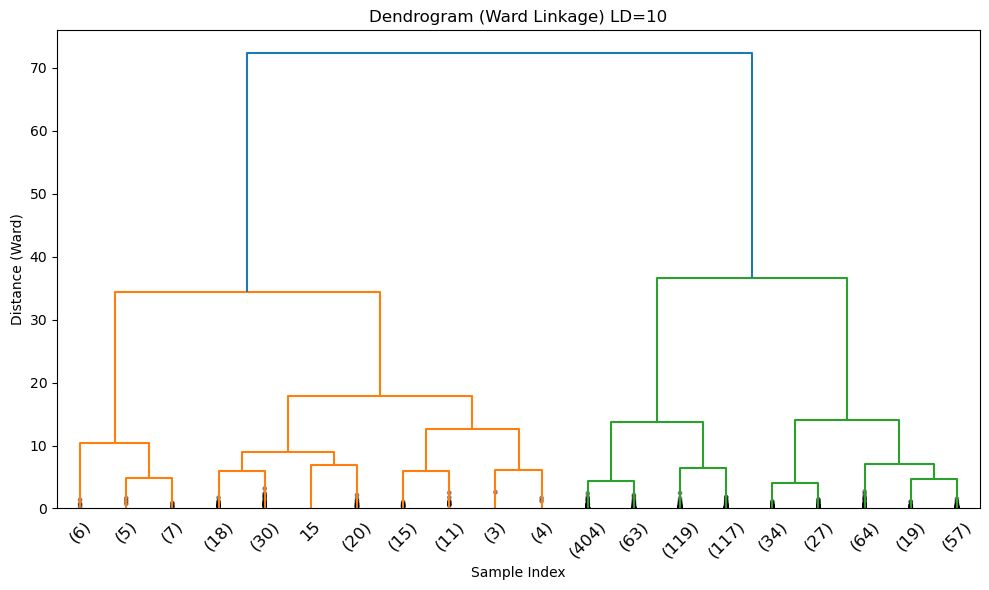

In [14]:
plt.figure(figsize=(10, 6))
dendrogram(
    linked_ld10, 
    truncate_mode='lastp',  
    p=20,                  
    leaf_rotation=45.,
    leaf_font_size=12.,
    show_contracted=True
)
plt.title('Dendrogram (Ward Linkage) LD=10')
plt.xlabel('Sample Index')
plt.ylabel('Distance (Ward)')
plt.tight_layout()
plt.show()

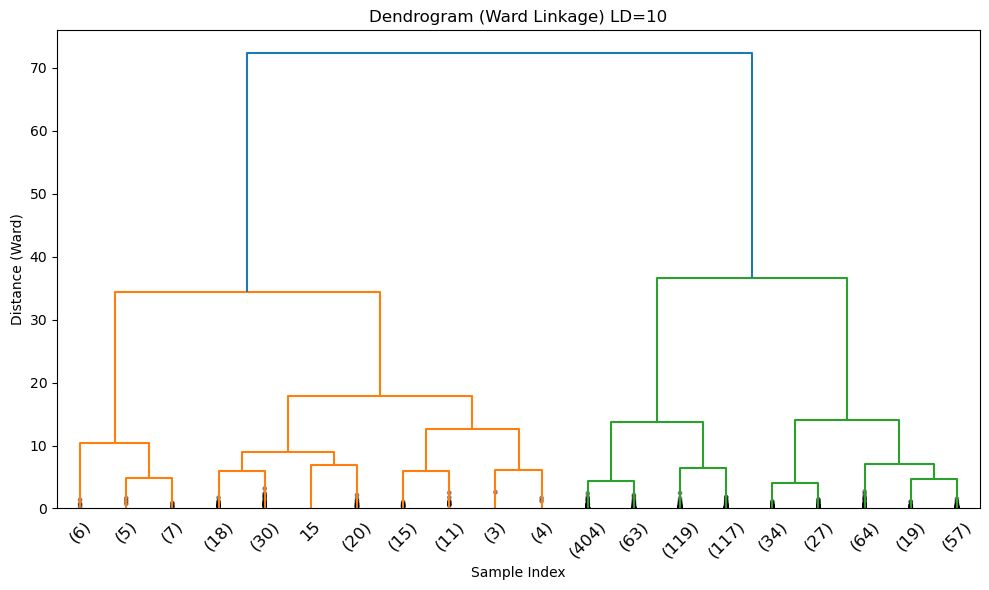

In [15]:
plt.figure(figsize=(10, 6))
dendrogram(
    linked_ld10, 
    truncate_mode='lastp',  
    p=20,                  
    leaf_rotation=45.,
    leaf_font_size=12.,
    show_contracted=True
)
plt.title('Dendrogram (Ward Linkage) LD=10')
plt.xlabel('Sample Index')
plt.ylabel('Distance (Ward)')
plt.tight_layout()
plt.show()

In [16]:
cluster_encoder = LabelEncoder()
cluster_labels_num = cluster_encoder.fit_transform(cluster_labels_10)

ari_10 = adjusted_rand_score(labels, cluster_labels_10)
homogeneity_10 = homogeneity_score(labels, cluster_labels_10)
completeness_10 = completeness_score(labels, cluster_labels_10)

print(f"Adjusted Rand Index (ARI):, {ari_10:.3f}")
print(f"Homogeneity: {homogeneity_10:.3f}")
print(f"Completeness: {completeness_10:.3f}")

Adjusted Rand Index (ARI):, -0.009
Homogeneity: 0.034
Completeness: 0.064


# All

## LD=2

Loading data.

In [17]:
ld2_all = np.load('../../best_models/ld2_ausio2_all.npy')
labels = np.load('../../dataset_TipAu_SiO2_annotated.npz')['labels']

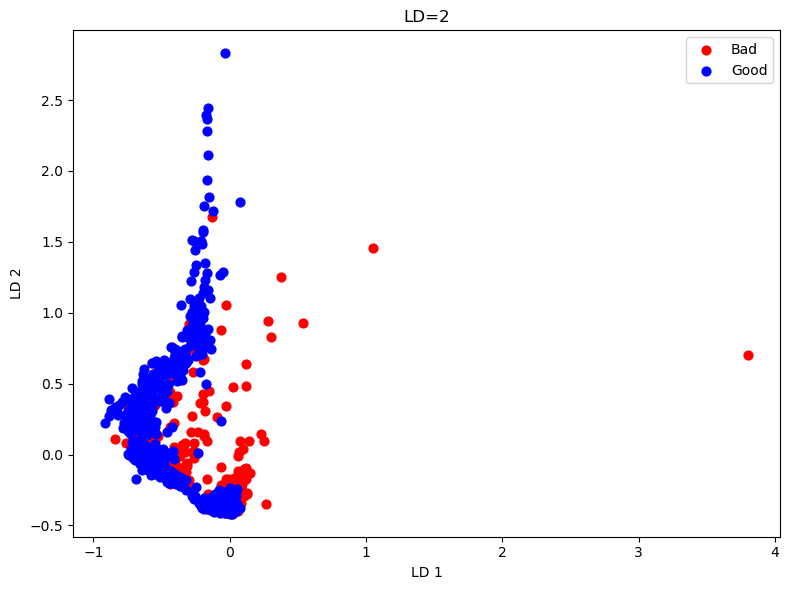

In [18]:
colors = ['red', 'blue']

plt.figure(figsize=(8, 6))
plt.scatter(ld2_all[labels == 0][:, 0], ld2_all[labels == 0][:, 1], label='Bad', s=40, color=colors[0])
plt.scatter(ld2_all[labels == 1][:, 0], ld2_all[labels == 1][:, 1], label='Good', s=40, color=colors[1])
plt.legend()
plt.title("LD=2")
plt.xlabel("LD 1")
plt.ylabel("LD 2")
plt.tight_layout()
plt.show()

Clustering LD=2 with Ward hierarchical clustering.

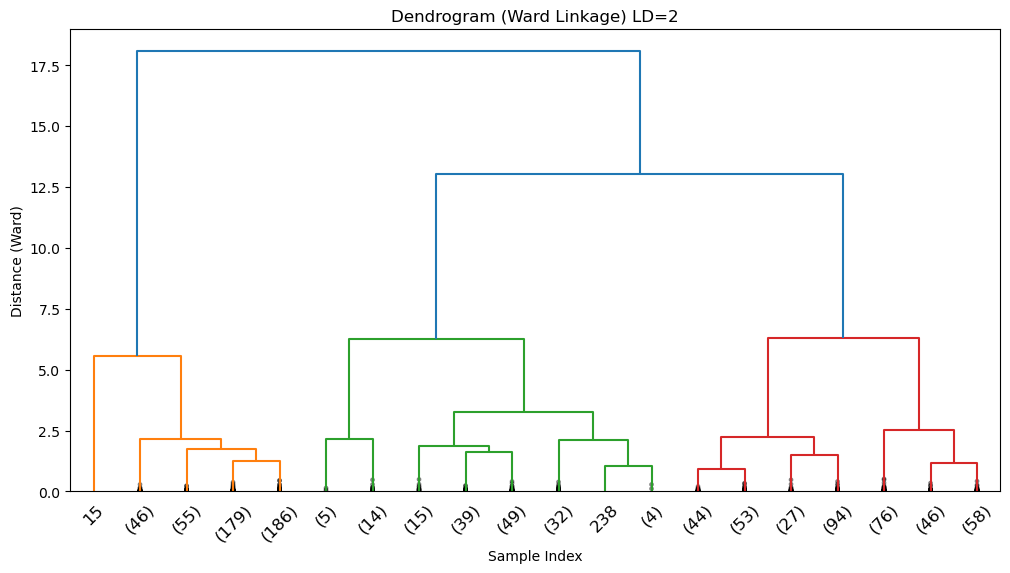

In [19]:
linked_ld2 = linkage(ld2_all, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(
    linked_ld2, 
    truncate_mode='lastp',  
    p=20,                  
    leaf_rotation=45.,
    leaf_font_size=12.,
    show_contracted=True
)
plt.title('Dendrogram (Ward Linkage) LD=2')
plt.xlabel('Sample Index')
plt.ylabel('Distance (Ward)')
plt.show()

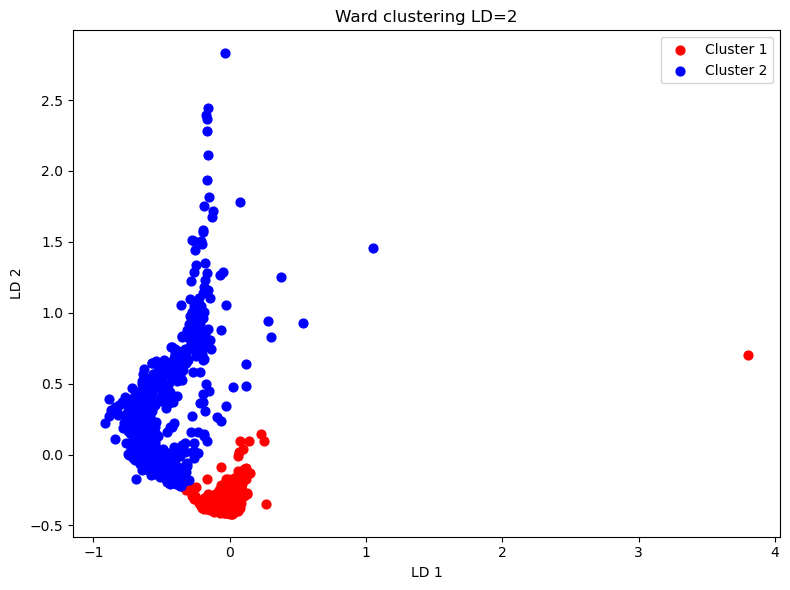

In [20]:
cluster_labels_ld2 = fcluster(linked_ld2, t=2, criterion='maxclust')

plt.figure(figsize=(8, 6))
for cluster_id in np.unique(cluster_labels_ld2):
    mask = (cluster_labels_ld2 == cluster_id)
    plt.scatter(ld2_all[mask, 0], ld2_all[mask, 1], label=f"Cluster {cluster_id}", s=40, c=colors[cluster_id - 1])
plt.legend()
plt.title("Ward clustering LD=2")
plt.xlabel("LD 1")
plt.ylabel("LD 2")
plt.tight_layout()
plt.show()

In [21]:
cluster_encoder = LabelEncoder()
cluster_labels_num = cluster_encoder.fit_transform(cluster_labels_ld2)

ari = adjusted_rand_score(labels, cluster_labels_ld2)
hom = homogeneity_score(labels, cluster_labels_ld2)
comp = completeness_score(labels, cluster_labels_ld2)

print(f"Ajusted Rand Index (ARI): {ari:.3f}")
print(f"Homogeneinity: {hom:.3f}")
print(f"Completeness: {comp:.3f}")

Ajusted Rand Index (ARI): 0.140
Homogeneinity: 0.101
Completeness: 0.100


## LD=3

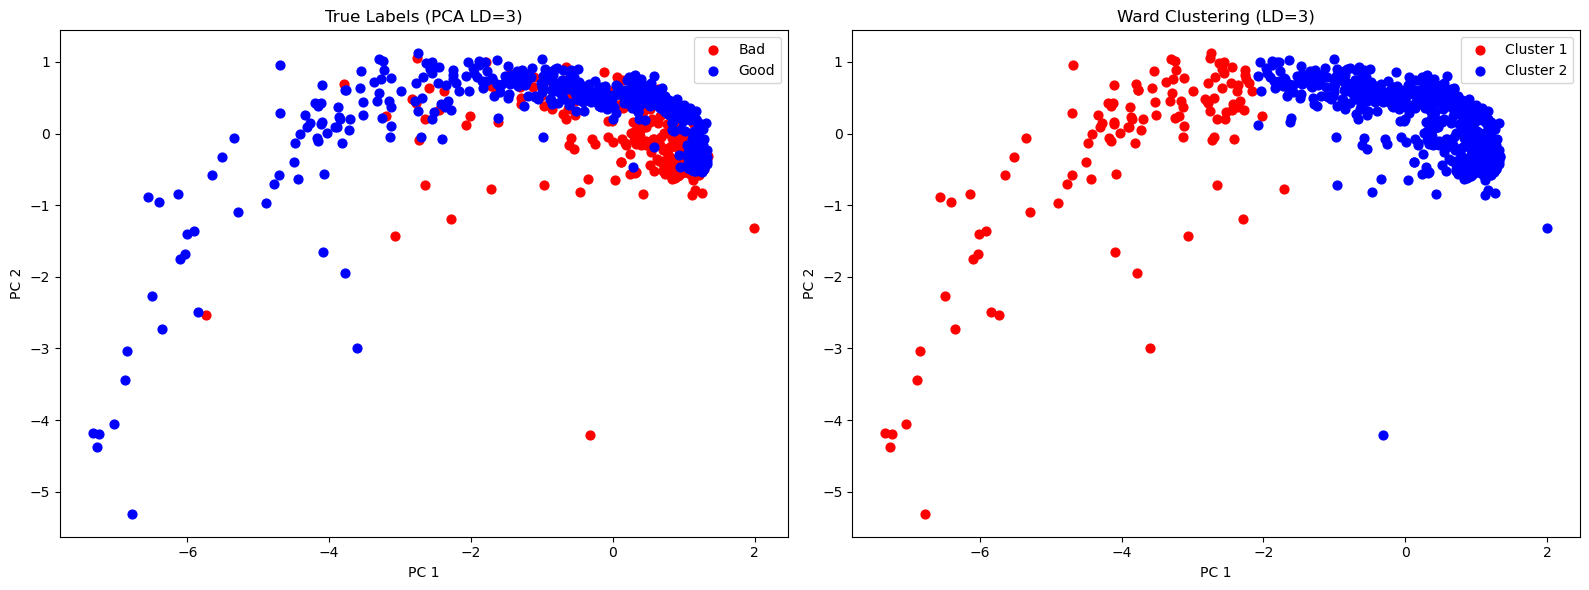

In [22]:
ld3_all = np.load('../../best_models/ld3_ausio2_all.npy')
labels = np.load('../../dataset_TipAu_SiO2_annotated.npz')['labels']

linked_ld3 = linkage(ld3_all, method='ward')
cluster_labels_3 = fcluster(linked_ld3, t=2, criterion='maxclust')

pca = PCA(n_components=2)
ld3_pca = pca.fit_transform(ld3_all)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6)) 

ax1.scatter(ld3_pca[labels == 0][:, 0], ld3_pca[labels == 0][:, 1], label='Bad', s=40, color=colors[0])
ax1.scatter(ld3_pca[labels == 1][:, 0], ld3_pca[labels == 1][:, 1], label='Good', s=40, color=colors[1])
ax1.set_title("True Labels (PCA LD=3)")
ax1.set_xlabel("PC 1")
ax1.set_ylabel("PC 2")
ax1.legend()

for cluster_id in np.unique(cluster_labels_3):
    mask = (cluster_labels_3 == cluster_id)
    ax2.scatter(ld3_pca[mask, 0], ld3_pca[mask, 1], 
                label=f"Cluster {cluster_id}", s=40, c=colors[cluster_id - 1])
ax2.set_title("Ward Clustering (LD=3)")
ax2.set_xlabel("PC 1")
ax2.set_ylabel("PC 2")
ax2.legend()

plt.tight_layout()
plt.show()

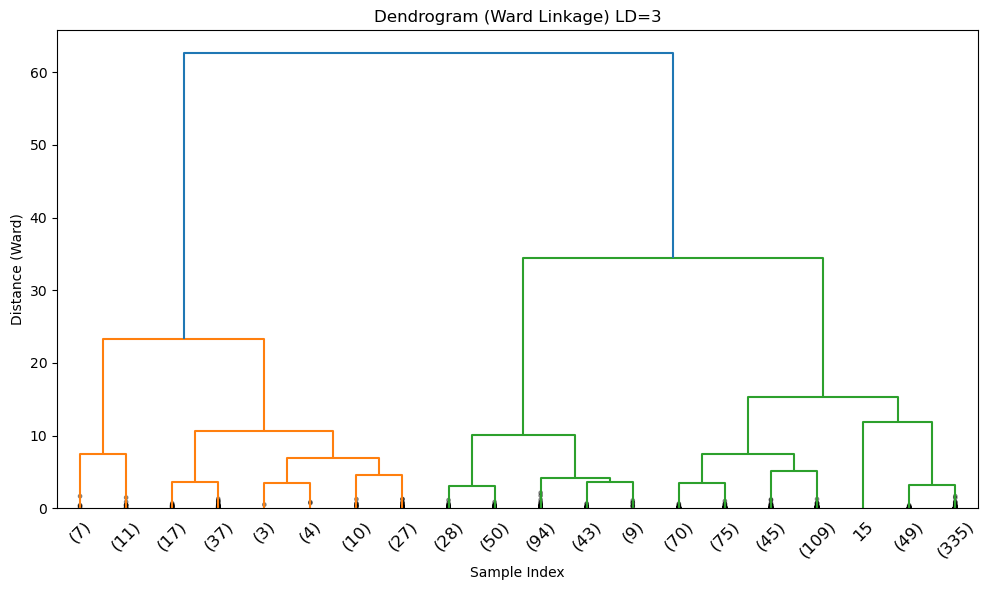

In [23]:
plt.figure(figsize=(10, 6))
dendrogram(
    linked_ld3, 
    truncate_mode='lastp',  
    p=20,                  
    leaf_rotation=45.,
    leaf_font_size=12.,
    show_contracted=True
)
plt.title('Dendrogram (Ward Linkage) LD=3')
plt.xlabel('Sample Index')
plt.ylabel('Distance (Ward)')
plt.tight_layout()
plt.show()

In [24]:
cluster_encoder = LabelEncoder()
cluster_labels_num = cluster_encoder.fit_transform(cluster_labels_3)

ari_3 = adjusted_rand_score(labels, cluster_labels_3)
homogeneity_3 = homogeneity_score(labels, cluster_labels_3)
completeness_3 = completeness_score(labels, cluster_labels_3)

print(f"Adjusted Rand Index (ARI):, {ari_3:.3f}")
print(f"Homogeneity: {homogeneity_3:.3f}")
print(f"Completeness: {completeness_3:.3f}")

Adjusted Rand Index (ARI):, -0.009
Homogeneity: 0.038
Completeness: 0.074


## LD=5

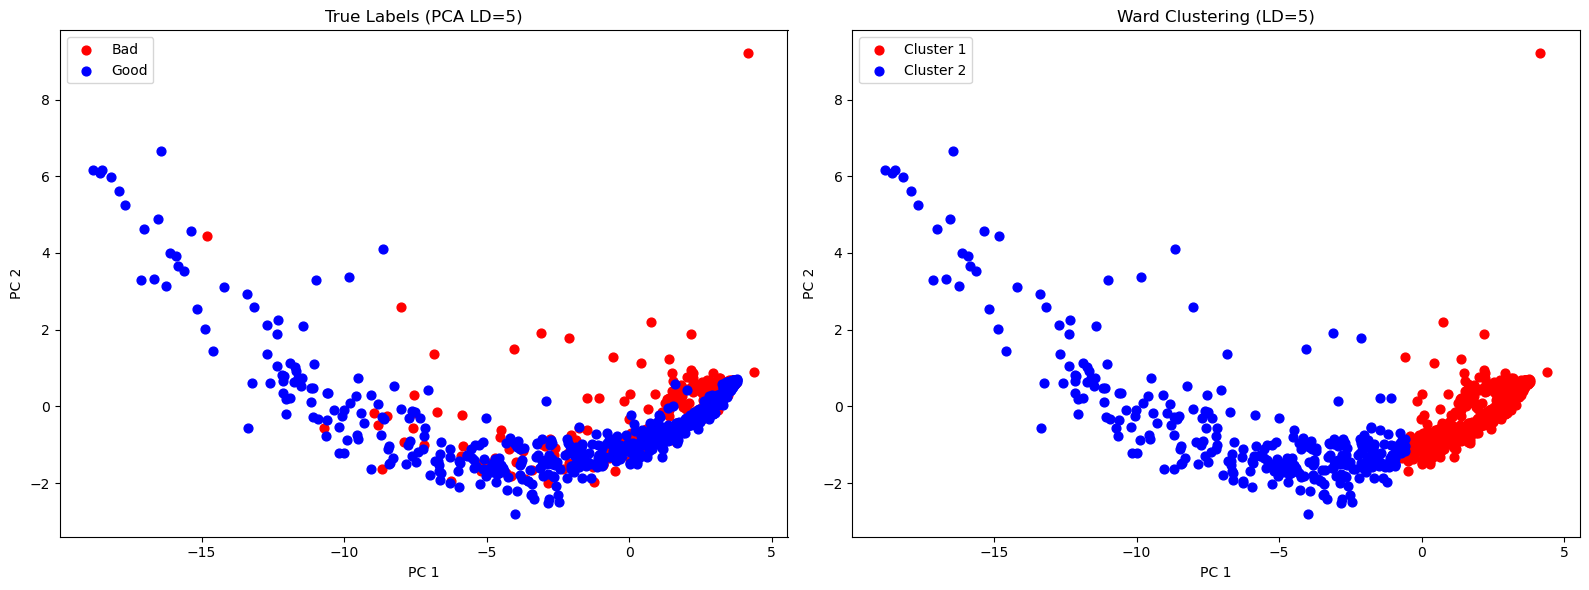

In [25]:
ld5_all = np.load('../../best_models/ld5_ausio2_all.npy')
labels = np.load('../../dataset_TipAu_SiO2_annotated.npz')['labels']

linked_ld5 = linkage(ld5_all, method='ward')
cluster_labels_5 = fcluster(linked_ld5, t=2, criterion='maxclust')

pca = PCA(n_components=2)
ld5_pca = pca.fit_transform(ld5_all)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6)) 

ax1.scatter(ld5_pca[labels == 0][:, 0], ld5_pca[labels == 0][:, 1], label='Bad', s=40, color=colors[0])
ax1.scatter(ld5_pca[labels == 1][:, 0], ld5_pca[labels == 1][:, 1], label='Good', s=40, color=colors[1])
ax1.set_title("True Labels (PCA LD=5)")
ax1.set_xlabel("PC 1")
ax1.set_ylabel("PC 2")
ax1.legend()

for cluster_id in np.unique(cluster_labels_5):
    mask = (cluster_labels_5 == cluster_id)
    ax2.scatter(ld5_pca[mask, 0], ld5_pca[mask, 1], 
                label=f"Cluster {cluster_id}", s=40, c=colors[cluster_id - 1])
ax2.set_title("Ward Clustering (LD=5)")
ax2.set_xlabel("PC 1")
ax2.set_ylabel("PC 2")
ax2.legend()

plt.tight_layout()
plt.show()

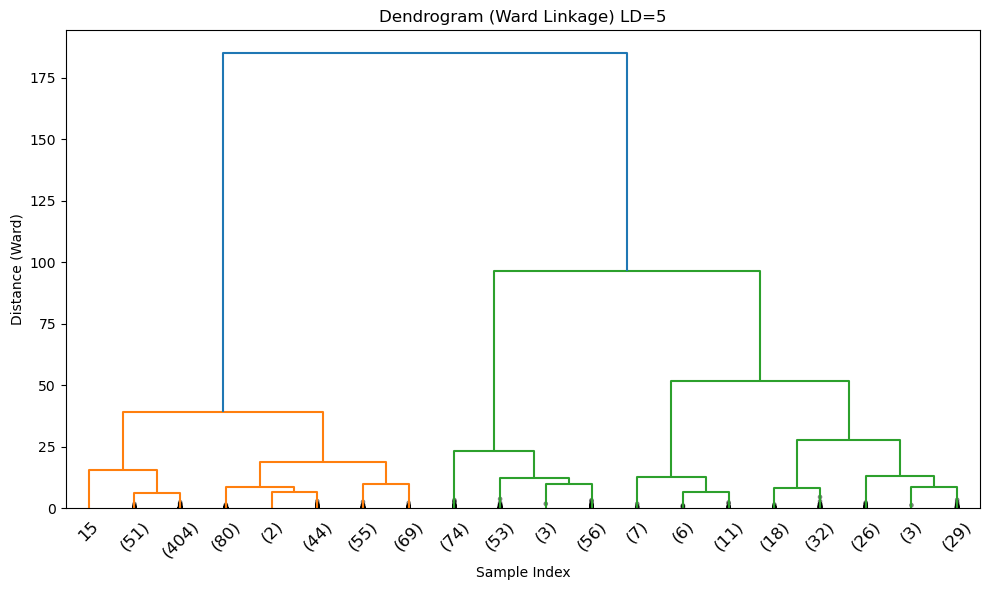

In [26]:
plt.figure(figsize=(10, 6))
dendrogram(
    linked_ld5, 
    truncate_mode='lastp',  
    p=20,                  
    leaf_rotation=45.,
    leaf_font_size=12.,
    show_contracted=True
)
plt.title('Dendrogram (Ward Linkage) LD=5')
plt.xlabel('Sample Index')
plt.ylabel('Distance (Ward)')
plt.tight_layout()
plt.show()

In [27]:
cluster_encoder = LabelEncoder()
cluster_labels_num = cluster_encoder.fit_transform(cluster_labels_5)

ari_5 = adjusted_rand_score(labels, cluster_labels_5)
homogeneity_5 = homogeneity_score(labels, cluster_labels_5)
completeness_5 = completeness_score(labels, cluster_labels_5)

print(f"Adjusted Rand Index (ARI):, {ari_5:.3f}")
print(f"Homogeneity: {homogeneity_5:.3f}")
print(f"Completeness: {completeness_5:.3f}")

Adjusted Rand Index (ARI):, 0.067
Homogeneity: 0.090
Completeness: 0.099


## LD=10

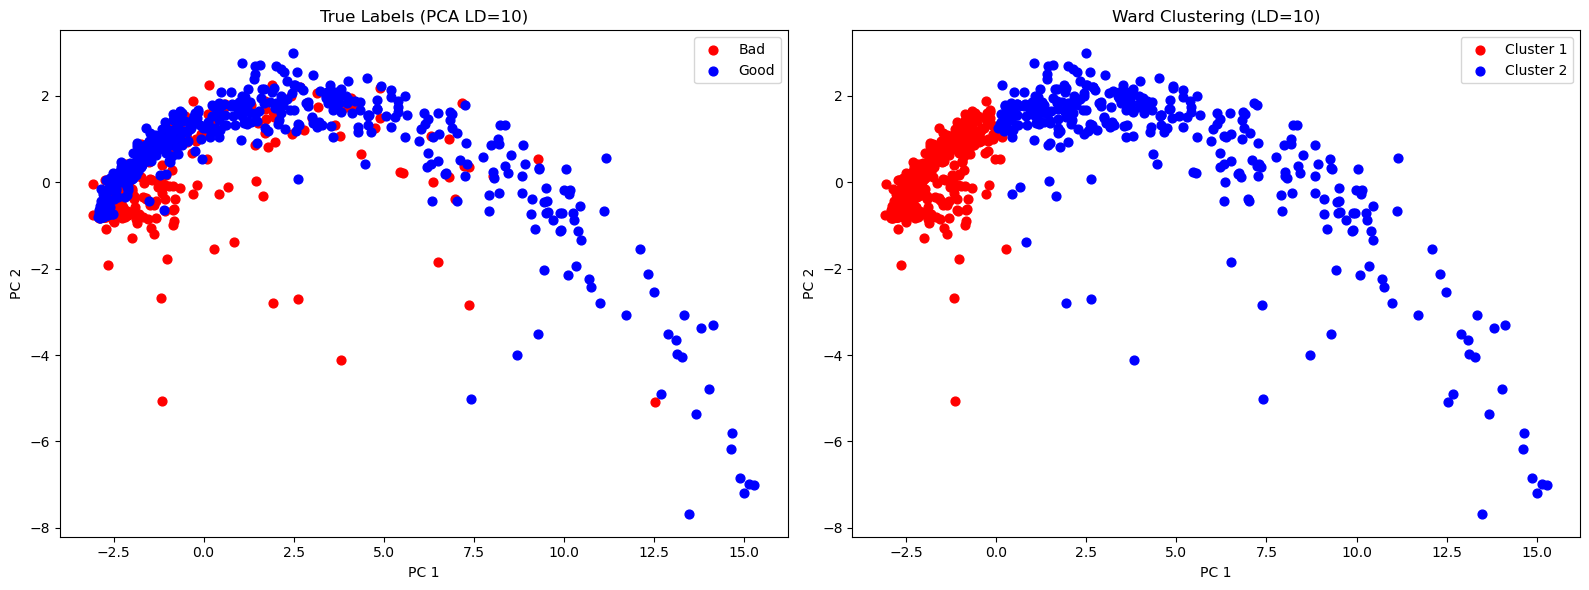

In [28]:
ld10_all = np.load('../../best_models/ld10_ausio2_all.npy')
labels = np.load('../../dataset_TipAu_SiO2_annotated.npz')['labels']

linked_ld10 = linkage(ld10_all, method='ward')
cluster_labels_10 = fcluster(linked_ld10, t=2, criterion='maxclust')

pca = PCA(n_components=2)
ld10_pca = pca.fit_transform(ld10_all)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6)) 

ax1.scatter(ld10_pca[labels == 0][:, 0], ld10_pca[labels == 0][:, 1], label='Bad', s=40, color=colors[0])
ax1.scatter(ld10_pca[labels == 1][:, 0], ld10_pca[labels == 1][:, 1], label='Good', s=40, color=colors[1])
ax1.set_title("True Labels (PCA LD=10)")
ax1.set_xlabel("PC 1")
ax1.set_ylabel("PC 2")
ax1.legend()

for cluster_id in np.unique(cluster_labels_10):
    mask = (cluster_labels_10 == cluster_id)
    ax2.scatter(ld10_pca[mask, 0], ld10_pca[mask, 1], 
                label=f"Cluster {cluster_id}", s=40, c=colors[cluster_id - 1])
ax2.set_title("Ward Clustering (LD=10)")
ax2.set_xlabel("PC 1")
ax2.set_ylabel("PC 2")
ax2.legend()

plt.tight_layout()
plt.show()

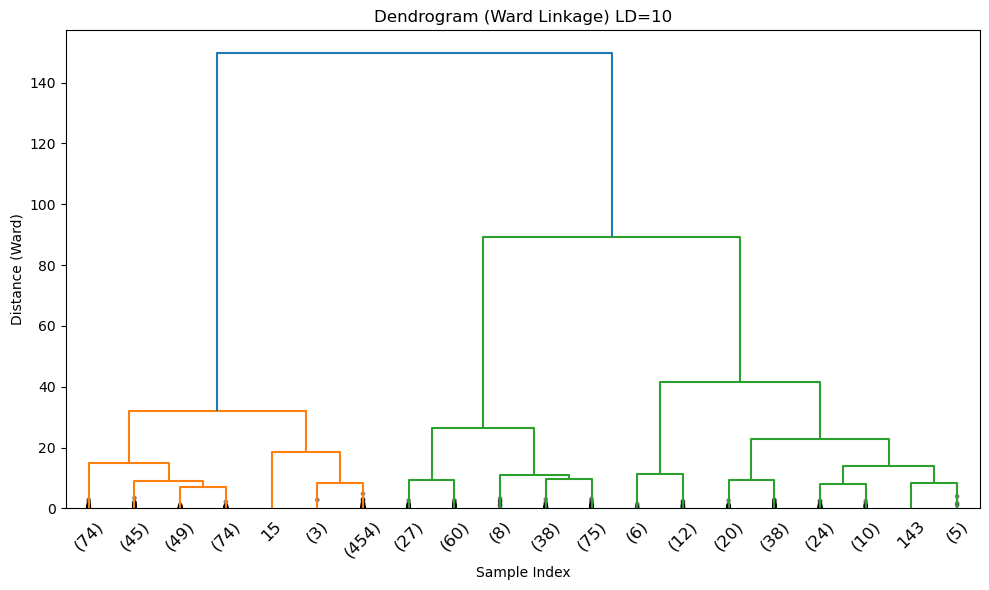

In [29]:
plt.figure(figsize=(10, 6))
dendrogram(
    linked_ld10, 
    truncate_mode='lastp',  
    p=20,                  
    leaf_rotation=45.,
    leaf_font_size=12.,
    show_contracted=True
)
plt.title('Dendrogram (Ward Linkage) LD=10')
plt.xlabel('Sample Index')
plt.ylabel('Distance (Ward)')
plt.tight_layout()
plt.show()

In [30]:
cluster_encoder = LabelEncoder()
cluster_labels_num = cluster_encoder.fit_transform(cluster_labels_10)

ari_10 = adjusted_rand_score(labels, cluster_labels_10)
homogeneity_10 = homogeneity_score(labels, cluster_labels_10)
completeness_10 = completeness_score(labels, cluster_labels_10)

print(f"Adjusted Rand Index (ARI):, {ari_10:.3f}")
print(f"Homogeneity: {homogeneity_10:.3f}")
print(f"Completeness: {completeness_10:.3f}")

Adjusted Rand Index (ARI):, 0.065
Homogeneity: 0.086
Completeness: 0.094
